# CNN전이학습_data_augmentation
* 전이학습: 사전에 훈련된 모델을 가져와서 사용하는 것
* data_augmentation: 이미지 데이터의 경우 데이터가 적어서 확보가 어려움, 비쌈이터가 적어서 확보가 어려움, 비쌈, 기존 이미지 데이터에 변형을 가해서 데이터 수를 늘리는 작업(회전, 확대, 축소, 자르기)

# Image Augmentation
* 학습데이터 부족을 해결하기 위해서 이미지에 변형을 가해 새로운 이미지를 만들어 주는 것

In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, array_to_img, load_img

2025-05-20 05:30:06.673217: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-20 05:30:06.704627: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-20 05:30:06.742714: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-20 05:30:06.752812: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-20 05:30:06.773620: I tensorflow/core/platform/cpu_feature_guar

In [2]:
image = load_img("./catanddog/bird.jpg")
image_array = img_to_array(image)
image_array.shape

(703, 454, 3)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

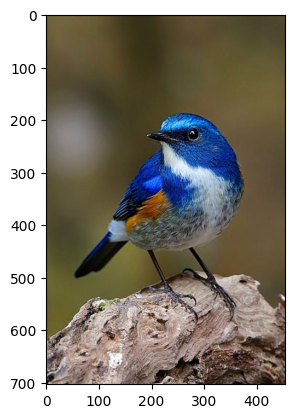

In [4]:
plt.imshow(image)
plt.show()

# Image Augmentation(이미지 증폭)

In [5]:
imggen = ImageDataGenerator(
            rescale= 1./255,
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode='nearest'
            )

In [6]:
image_array.shape

(703, 454, 3)

차원 늘리기

In [7]:
# image_array.reshape((1,) + image_array.shape).shape

In [8]:
image_array = image_array.reshape((1,) + image_array.shape)
image_array.shape

(1, 703, 454, 3)

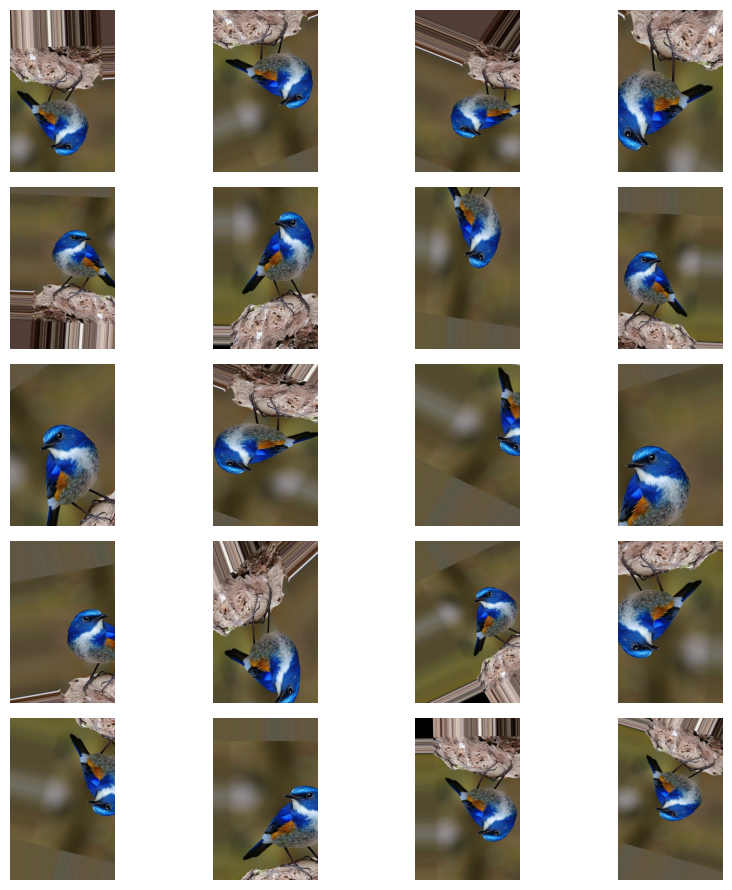

In [9]:
fig, axes = plt.subplots(5, 4, figsize=(9,9))
axes = axes.ravel()

for i, batch in enumerate(imggen.flow(image_array, batch_size=1)):
    if i >= 20:
        break
    augmented_image = array_to_img(batch[0])
    axes[i].imshow(augmented_image)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# image_augmentation을 이용한 개/고양이 분류모델 만들기

In [10]:
# 데이터 로드
train_dir = "./catanddog/train/"
valid_dir = "./catanddog/validation/"
batch_size = 16 # 한 번에 불러오는 사진의 개수, 분석 모델에 따라서 16(큼) ~ 32(작음) 사이로 지정
image_size = (224, 224) # 모델의 입력 크기에 맞춤

In [11]:
# 이미지 증강
train_aug = ImageDataGenerator(
            rescale=1./255,
            rotation_range=40,
            width_shift_range=0.3,
            height_shift_range=0.2,
            shear_range=0.6,
            zoom_range=0.3,
            fill_mode='nearest'
            )

valid_aug = ImageDataGenerator(rescale=1./255)

# 이미지 제너레이터
train_gen = train_aug.flow_from_directory(
            train_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

valid_gen = valid_aug.flow_from_directory(
            valid_dir,
            target_size=image_size,
            batch_size=batch_size,
            class_mode='categorical',
            shuffle=True,
            seed=42
            )

X_batch, y_batch = next(train_gen)
print(X_batch.shape)
print(y_batch.shape)
print(train_gen.class_indices)

Found 2222 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
(16, 224, 224, 3)
(16, 2)
{'Cat': 0, 'Dog': 1}


# CNN을 이용한 개/고양이 분류

In [12]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [13]:
cnn_model = Sequential()
cnn_model.add(Input(shape=(224, 224, 3)))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation="relu"))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(64, kernel_size=(3,3), activation="relu"))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Conv2D(32, kernel_size=(3,3), activation="relu"))
cnn_model.add(MaxPooling2D(2,2))
cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation="relu"))
cnn_model.add(Dropout(0.25))
cnn_model.add(Dense(64, activation="relu"))
cnn_model.add(Dense(2, activation="softmax"))
cnn_model.summary()

I0000 00:00:1747719018.657866    5087 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747719018.671706    5087 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747719018.671781    5087 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747719018.679504    5087 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1747719018.679657    5087 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 21632)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,769,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,815,266 (10.74 MB)

 Trainable params: 2,815,266 (10.74 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
import tensorflow as tf

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/1000


I0000 00:00:1747719026.711064    5161 service.cc:146] XLA service 0x7f10b8020140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747719026.711174    5161 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-20 05:30:26.842201: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-20 05:30:27.530560: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
2025-05-20 05:30:37.060649: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng4{k11=1} for conv (f32[16,64,54,54]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,32,52,52]{3,2,1,0}, f32[32,64,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudn

126/139 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5315 - loss: 0.6950

2025-05-20 05:33:33.530311: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng4{k11=1} for conv (f32[14,32,111,111]{3,2,1,0}, u8[0]{0}) custom-call(f32[14,64,109,109]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
E0000 00:00:1747719214.280108    5160 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747719215.398387    5160 gpu_timer.cc:183] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1747719216.577897

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5300 - loss: 0.6949
Epoch 1: val_loss improved from inf to 0.68878, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 247s 1s/step - accuracy: 0.5299 - loss: 0.6949 - val_accuracy: 0.5000 - val_loss: 0.6888
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.5119 - loss: 0.6933
Epoch 2: val_loss improved from 0.68878 to 0.68259, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 123s 881ms/step - accuracy: 0.5120 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6826
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.5204 - loss: 0.6925
Epoch 3: val_loss improved from 0.68259 to 0.67408, saving model to ./model/cnn_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 132s 810ms/step - accuracy: 0.5205 - loss: 0.6925 - val_accuracy: 0.6224 - val_loss: 0.6741
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 874ms/step - accuracy: 0.5705 - loss: 0.6843
Epoch 4: val_loss 

Epoch 25/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.6900 - loss: 0.5965
Epoch 25: val_loss did not improve from 0.54145
139/139 ━━━━━━━━━━━━━━━━━━━━ 58s 417ms/step - accuracy: 0.6900 - loss: 0.5965 - val_accuracy: 0.7245 - val_loss: 0.5525
Epoch 26/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.6981 - loss: 0.5924
Epoch 26: val_loss did not improve from 0.54145
139/139 ━━━━━━━━━━━━━━━━━━━━ 60s 434ms/step - accuracy: 0.6981 - loss: 0.5925 - val_accuracy: 0.7041 - val_loss: 0.5640
Epoch 27/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step - accuracy: 0.6739 - loss: 0.6031
Epoch 27: val_loss did not improve from 0.54145
139/139 ━━━━━━━━━━━━━━━━━━━━ 69s 497ms/step - accuracy: 0.6739 - loss: 0.6030 - val_accuracy: 0.7041 - val_loss: 0.5598
Epoch 28/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.6716 - loss: 0.6085
Epoch 28: val_loss did not improve from 0.54145
139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 454ms/step - accuracy: 0.6717 - loss: 0.6084 - val_

139/139 ━━━━━━━━━━━━━━━━━━━━ 53s 381ms/step - accuracy: 0.7284 - loss: 0.5571 - val_accuracy: 0.7143 - val_loss: 0.6262
Epoch 50/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.7274 - loss: 0.5535
Epoch 50: val_loss did not improve from 0.50511
139/139 ━━━━━━━━━━━━━━━━━━━━ 52s 374ms/step - accuracy: 0.7273 - loss: 0.5534 - val_accuracy: 0.7041 - val_loss: 0.5093
Epoch 51/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.7102 - loss: 0.5436
Epoch 51: val_loss did not improve from 0.50511
139/139 ━━━━━━━━━━━━━━━━━━━━ 52s 371ms/step - accuracy: 0.7103 - loss: 0.5435 - val_accuracy: 0.7551 - val_loss: 0.5131
Epoch 52/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.7394 - loss: 0.5193
Epoch 52: val_loss did not improve from 0.50511
139/139 ━━━━━━━━━━━━━━━━━━━━ 50s 359ms/step - accuracy: 0.7393 - loss: 0.5194 - val_accuracy: 0.6837 - val_loss: 0.5195
Epoch 53/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.7455 - loss: 0.5169
Epoch 53: va

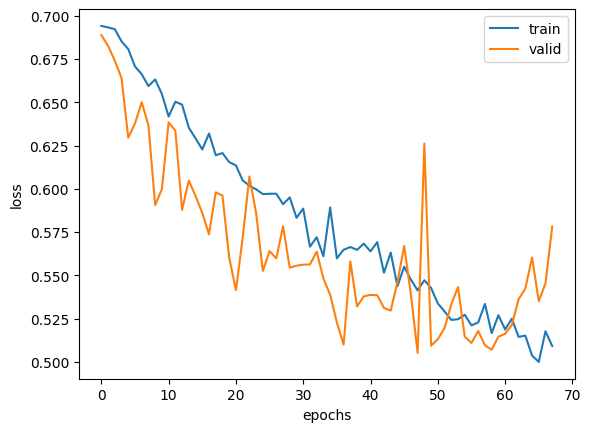

In [15]:
cnn_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/cnn_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
cnn_history = cnn_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(cnn_history.history['loss'])
plt.plot(cnn_history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


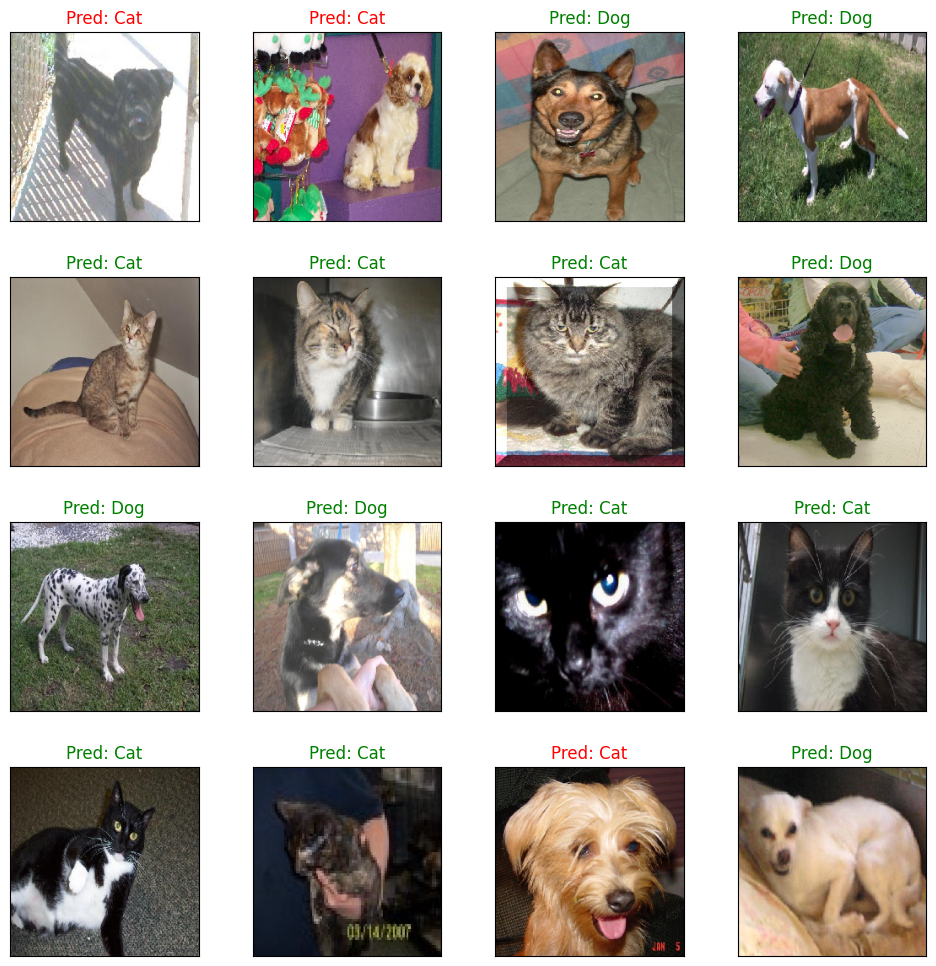


cnn_best_model평가 결과: Loss: 0.3685, Accuracy: 0.8125


In [16]:
# best 모델 로드
cnn_best_model = load_model("./model/cnn_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

cnn_pred = cnn_best_model.predict(validation_batch)
pred_values = np.argmax(cnn_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = cnn_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\ncnn_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# 전이학습
* 사전에 훈련된 모델을 가지고 새로운 데이터를 넣어서 튜닝을 하거나 결과를 출력
* keras.applications에 있음

# ResNet50

In [17]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50, ResNet152V2

In [20]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_tensor=None,
    input_shape=(224,224,3),
    pooling='avg')

In [21]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [22]:
base_model.trainable = False
res50_model = Sequential()
res50_model.add(base_model)
res50_model.add(Dense(2, activation='softmax'))
res50_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
res50_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res50_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
res50_history = res50_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(res50_history.history['loss'])
plt.plot(res50_history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

Epoch 1/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4810 - loss: 0.8981
Epoch 1: val_loss improved from inf to 0.70071, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 298s 2s/step - accuracy: 0.4810 - loss: 0.8972 - val_accuracy: 0.4898 - val_loss: 0.7007
Epoch 2/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4784 - loss: 0.7001
Epoch 2: val_loss improved from 0.70071 to 0.69637, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 225s 2s/step - accuracy: 0.4785 - loss: 0.7000 - val_accuracy: 0.4898 - val_loss: 0.6964
Epoch 3/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4624 - loss: 0.6990
Epoch 3: val_loss improved from 0.69637 to 0.69425, saving model to ./model/res50_catndog.keras
139/139 ━━━━━━━━━━━━━━━━━━━━ 236s 2s/step - accuracy: 0.4625 - loss: 0.6990 - val_accuracy: 0.4796 - val_loss: 0.6942
Epoch 4/1000
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4897 - loss: 0.6959
Epoch 4: val_l

KeyboardInterrupt: 

In [ ]:
# best 모델 로드
res50_best_model = load_model("./model/res50_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

res50_pred = res50_best_model.predict(validation_batch)
pred_values = np.argmax(res50_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = res50_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres50_best_model평가 결[[과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# ResNet152V2

In [ ]:
base_model2 = ResNet152V2(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3),
    pooling='avg')

In [ ]:
base_model2.summary()

In [ ]:
base_model2.trainable = False
res152v2_model = Sequential()
res152v2_model.add(base_model2)
res152v2_model.add(Dense(2, activation="softmax"))

In [ ]:
res152v2_model.compile(loss='categorical_crossentropy', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  metrics=['accuracy'])
model_path = "./model/res50_catndog.keras"
check_point = ModelCheckpoint(model_path, save_best_only=True, monitor='val_loss', verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
res152v2_history = res152v2_model.fit(train_gen, epochs=1000, validation_data=valid_gen,
                           callbacks=[early_stop, check_point])
plt.plot(res152v2_history.history['loss'])
plt.plot(res152v2_history.history['val_loss'])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend(['train', 'valid'])
plt.show()

In [ ]:
# best 모델 로드
res152v2_best_model = load_model("./model/res152v2_catndog.keras")

# 클래스 이름 추출하기
class_indices = valid_gen.class_indices
class_names = [k for k, v in sorted(class_indices.items(), key=lambda x: x[1])]
validation_batch, label_batch = next(iter(valid_gen))

res152v2_pred = res152v2_best_model.predict(validation_batch)
pred_values = np.argmax(res152v2_pred, axis=1)
true_values = np.argmax(label_batch, axis=1)

fig = plt.figure(figsize=(12,12))
fig.subplots_adjust(hspace=0.3)

num_images = min(16, validation_batch.shape[0])

for i in range(num_images):
    ax = fig.add_subplot(4, 4, i+1, xticks=[], yticks=[])
    ax.imshow(validation_batch[i], cmap=plt.cm.gray_r)
    
    pred_label = class_names[pred_values[i]]
    true_label = class_names[true_values[i]]
    color = 'green' if pred_values[i] == true_values[i] else 'red'
    ax.set_title(f"Pred: {pred_label}", color=color, fontsize=12)
plt.show()

# loss와 accuracy 출력
loss, acc = res152v2_best_model.evaluate(validation_batch, label_batch, verbose=0)
print(f"\nres152v2_best_model평가 결과: Loss: {loss:.4f}, Accuracy: {acc:.4f}")

# convnextbase로 분석하기

In [ ]:
from tensorflow.keras.applications import ConvNeXtBase

In [ ]:
base_model3 = ConvNeXtBase(
    include)